In [38]:
import warnings
warnings.filterwarnings('ignore')

In [170]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [40]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [119]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,235,Democrats
1,233,Democrats
2,249,Democrats
3,212,Republicans
4,250,Democrats
...,...,...
19995,223,Democrats
19996,213,Republicans
19997,256,Democrats
19998,204,Republicans


In [120]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,113,1,0.005,Republicans
1,152,1,0.005,Republicans
2,153,2,0.010,Republicans
3,155,1,0.005,Republicans
4,160,2,0.010,Republicans


In [113]:
np.unique(seat_sims['seats']).shape[0]

189

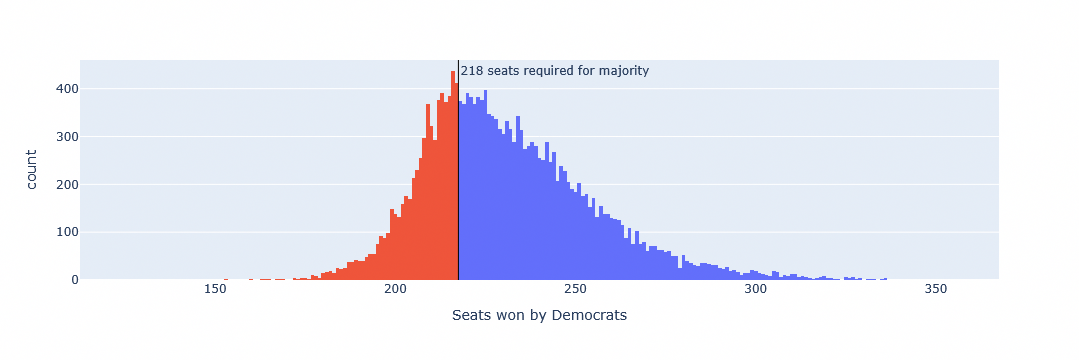

In [137]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [159]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [160]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-2.009394,-8.594692,-4.557779,-6.379687,-0.400741,-8.917795,0.539162,-6.789574,-5.003986,-2.641665,...,-2.011481,-2.643407,-5.490933,-2.240098,-4.016548,-4.510959,-10.122697,-1.263723,-10.570587,-3.018570
AL-01,-13.140352,-14.814895,-10.439000,-19.273221,-7.171333,-18.894211,-13.199306,-17.877998,-16.053299,-12.577491,...,-12.832913,-18.771166,-14.855605,-13.988534,-13.689050,-11.599134,-16.602552,-13.111012,-20.565193,-12.861562
AL-02,0.593115,0.984157,4.170103,-6.387942,4.495349,-7.861391,-2.491725,-4.897688,-8.718592,4.985829,...,-4.377748,-6.830845,-7.442581,0.203325,-4.223648,-9.103720,-1.493410,-4.750018,-6.384946,-5.914053
AL-03,-17.945926,-22.254533,-16.177948,-23.857795,-17.073654,-24.583310,-19.342478,-24.243391,-20.846831,-18.252611,...,-19.022731,-22.255688,-23.417588,-17.140351,-18.918431,-22.193769,-23.070701,-15.639602,-27.658213,-23.695655
AL-04,-30.183398,-32.601548,-29.451013,-35.395411,-25.876844,-36.091260,-27.569120,-31.308287,-29.050448,-31.365697,...,-30.450727,-32.767527,-33.006604,-27.950683,-29.728018,-32.630501,-35.888514,-29.363344,-37.871939,-29.003166


In [161]:
post.shape

(423, 20000)

In [165]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [167]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:31<00:00, 644.71it/s]


array(['ME-02', 'FL-16', 'CA-22', ..., 'FL-14', 'NY-17', 'PA-01'],
      shape=(20000,), dtype='<U32')

In [186]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-6.290199,-18.764506,-1,-37.529012,45.240550,3.684073,9.800,1,38.107666,52.433036
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-28.253876,-38.923019,0,-77.846039,35.985341,3.679425,0.000,2,28.798996,43.245346
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-6.423009,-19.716169,1,-39.432338,47.377706,3.608817,23.685,3,40.341435,54.397441
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-39.021777,-45.710827,-1,-91.421653,29.546074,3.570457,0.000,4,22.500298,36.542547
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-59.313873,-47.132870,-1,-94.265741,19.816490,3.607808,0.000,5,12.775941,26.921940


In [187]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-18.764506,-1,-37.529012,45.240550,3.684073,9.800,1,38.107666,52.433036,0.115
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-38.923019,0,-77.846039,35.985341,3.679425,0.000,2,28.798996,43.245346,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-19.716169,1,-39.432338,47.377706,3.608817,23.685,3,40.341435,54.397441,0.990
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-45.710827,-1,-91.421653,29.546074,3.570457,0.000,4,22.500298,36.542547,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-47.132870,-1,-94.265741,19.816490,3.607808,0.000,5,12.775941,26.921940,0.000


In [189]:
data.sort_values('tipping_point_prob', ascending=False).head(7)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,...,50.000000,0,100.000000,50.927587,3.775003,59.750,234,43.482578,58.284327,3.265
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",...,-3.195838,0,-6.391676,50.454463,3.764753,54.895,198,42.929038,57.817877,3.170
278,278,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",...,3.773526,-1,7.547052,50.671653,3.592414,57.305,279,43.659061,57.704226,2.935
98,98,FL-22,TBDFL-22,TBDFL-22,False,False,FL,22,no_match,no_match,...,-50.000000,0,0.000000,49.739539,3.753169,47.135,99,42.396736,57.127592,2.705
262,262,NY-01,Christopher Gallant,Nick LaLota,False,True,NY,1,"GALLANT, CHRISTOPHER",no_match,...,50.000000,-1,100.000000,50.204395,3.636961,52.385,263,43.042219,57.337184,2.625
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",...,12.732090,-1,25.464181,50.449407,3.557721,55.100,38,43.484447,57.407716,2.620
319,319,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",...,6.533790,-1,13.067581,50.288587,3.620836,53.155,320,43.219412,57.322065,2.550
